# Testing TorchDA with the Cahn-Hilliard Problem

The `forward_model` predicts the concentration based on $\gamma$. We want to vary $\gamma$ and try and see if we can predict the original value. We're solving

$$ \dot{\phi} = \nabla^2 \left( \phi^3 - \phi \right) - \gamma \nabla^4 \phi $$


In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.fft import fft2, ifft2
from torchda import apply_KF, apply_EnKF
import torch

device = "cpu"

In [178]:
def initial_c(N=256, c0=0.5):
    c = np.empty((N,N), dtype=np.float32)
    noise = 0.1
    rng = np.random.default_rng(12345) # the seed of random numbers generator
    return c0 + 0.1 * rng.standard_normal(c.shape)

In [179]:


def forward_model(c, nsteps=100, dt=0.1, dx=0.5, gamma=1.0):
    N = c.shape[0]
    c_hat = np.empty((N,N), dtype=np.complex64)
    dfdc_hat = np.empty((N,N), dtype=np.complex64)
    kx = ky = np.fft.fftfreq(N, d=dx)*2*np.pi
    K = np.array(np.meshgrid(kx , ky ,indexing ='ij'), dtype=np.float32)
    K2 = np.sum(K*K,axis=0, dtype=np.float32)

    c_store = np.empty((nsteps + 1, N, N), dtype=np.float32)
    c_store[0, :, :] = c
    
    # The anti-aliasing factor  
    kmax_dealias = kx.max() * 2.0 / 3.0 # The Nyquist mode
    dealias = np.array((np.abs(K[0]) < kmax_dealias) * (np.abs(K[1]) < kmax_dealias ),dtype =bool)

    def dfdc(c):
        return 2 * (c * (1 - c)**2 - (1 - c) * c**2)

    c_hat[:] = fft2(c)
    for i in range(1, nsteps + 1):
        dfdc_hat[:] = fft2(dfdc(c)) # the FT of the derivative
        dfdc_hat *= dealias # dealising
        c_hat[:] = (c_hat - dt * K2 * dfdc_hat) / (1 + dt * gamma * K2**2) # updating in time
        c = ifft2(c_hat).real # inverse fourier transform
        c_store[i, :, :] = c
        
    return c_store


(301, 128, 128)


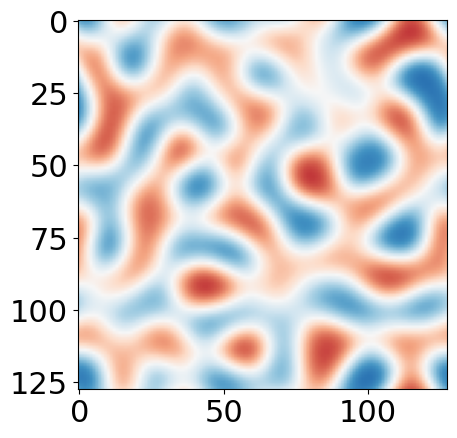

In [180]:

N = 128
gamma_obs = 2.0
nsteps = 300
c0 = initial_c(N=N, c0=0.5)
c_store = forward_model(c0, nsteps=nsteps, gamma=gamma_obs)

print(c_store.shape)

plt.imshow(c_store[-1],cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.show()

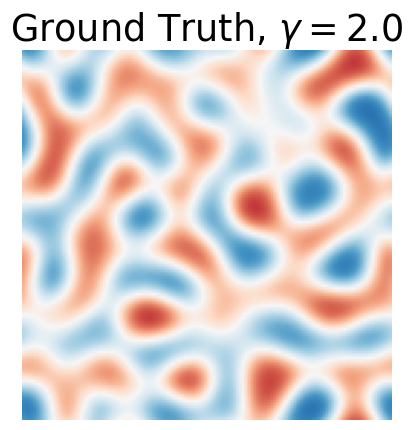

In [181]:
plt.imshow(c_store[-1],cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.title("Ground Truth, $\\gamma=2.0$")
plt.axis('off')
plt.savefig("ground-truth.png")
plt.show()

In [182]:
np.random.normal(0, 1e-2)

0.0013801074860394402

In [241]:
def run_filter(nobs_gap, sigens, siggamma, gamma_initial, prop):
    Ne = 50
    Nobs_domain = N * N // prop

    Nobs_steps = np.arange(nobs_gap, 301, nobs_gap)
    time_obs = torch.tensor(Nobs_steps, device=device)
    gaps = torch.tensor([nobs_gap] * len(time_obs), device=device)

    rng = np.random.default_rng(1228075288403)
    sample_i = rng.integers(0, high=N * N, size=Nobs_domain, dtype=int)
    def H(x):
        return x[:, sample_i + 1]

    def forwardModel_wrap(state_vector, time_steps):
        gamma = state_vector[0]  + np.random.normal(0, 1e-3)
        nsteps=len(time_steps) - 1
        c = np.array(state_vector[1:].reshape((N, N)))
        c_update = forward_model(c, nsteps, gamma=gamma)
        out = torch.zeros((nsteps + 1, len(state_vector)), dtype=state_vector.dtype, device=device)
        out[:, 0] = state_vector[0]
        out[:, 1:] = torch.tensor(c_update.reshape(c_update.shape[0], c_update.shape[1] * c_update.shape[2]), device=device)
        return out
        
#        return torch.tensor(out, device=device).reshape(out.shape[0], out.shape[1] * out.shape[2])

      # standard deviation of the ensemble
    sigobs = 1e-3
    # initial covariance matrix
    P0 = (sigens**2)*torch.eye(N * N + 1, device=device)
    P0[0, 0] = siggamma**2
    R = (sigobs**2) * torch.eye(Nobs_domain, device=device)

    x0ens = torch.zeros(N * N + 1, device=device)
    x0ens[0] = gamma_initial
    x0ens[1:] = torch.tensor(c_store[0].reshape(N * N), device=device)
    #x0ens = torch.tensor(c_store[0].reshape(N * N), device=device)

    y_obs_ = c_store[Nobs_steps, :].reshape(len(Nobs_steps), N * N)
    y_obs = torch.tensor(y_obs_[:, sample_i], device=device)

    xEnKF, x_ens = apply_EnKF(
        time_obs, gaps, Ne, forwardModel_wrap, H, P0, R, x0ens, y_obs
    )
    return xEnKF.T, x_ens.transpose(0, -1)

def calc_err(xEnKF, x_ens, c_store):
    def error(x, y):
        return np.sqrt(np.sum((x - y)**2, axis=-1))
    c_store_ = c_store.reshape(c_store.shape[0], N * N)
    err_mu = error(np.array(xEnKF.swapaxes(0, 1)), c_store_)
    err_ens = error(np.array(x_ens.swapaxes(0, 1).swapaxes(1, 2)), c_store_)
    return err_mu, err_ens

In [242]:
xEnKF, x_ens = run_filter(10, sigens=4e-3, siggamma=0.3, gamma_initial=gamma_obs - 1.0, prop=10)

/tmp/ipykernel_1840948/3639613577.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  c = np.array(state_vector[1:].reshape((N, N)))
/tmp/ipykernel_1840948/390200981.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  c_hat[:] = (c_hat - dt * K2 * dfdc_hat) / (1 + dt * gamma * K2**2) # updating in time
/tmp/ipykernel_1840948/390200981.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyw

In [243]:
err_mu, err_ens = calc_err(xEnKF[1:], x_ens[1:], c_store)

/tmp/ipykernel_1840948/3639613577.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  err_mu = error(np.array(xEnKF.swapaxes(0, 1)), c_store_)
/tmp/ipykernel_1840948/3639613577.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  err_ens = error(np.array(x_ens.swapaxes(0, 1).swapaxes(1, 2)), c_store_)


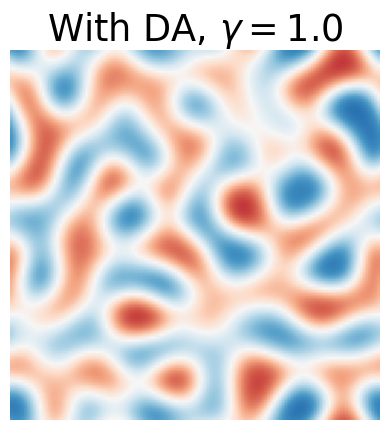

In [244]:
plt.imshow(xEnKF[1:,-1].reshape(N, N),cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.title("With DA, $\\gamma=1.0$")
plt.axis('off')
plt.savefig("with-da.png")
plt.show()

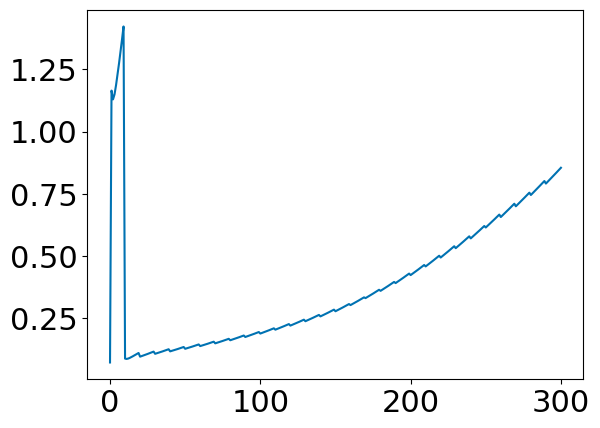

In [245]:
plt.plot(err_mu)

In [246]:
x_ens.shape

torch.Size([16385, 50, 301])

<Axes: ylabel='Count'>

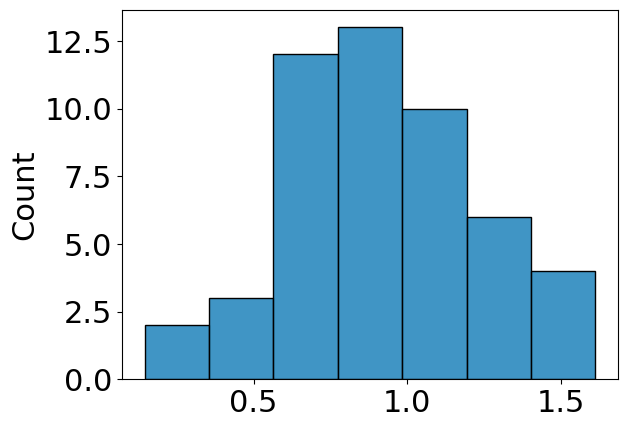

In [247]:
import seaborn
seaborn.histplot(x_ens[0, :, 0])

<Axes: ylabel='Count'>

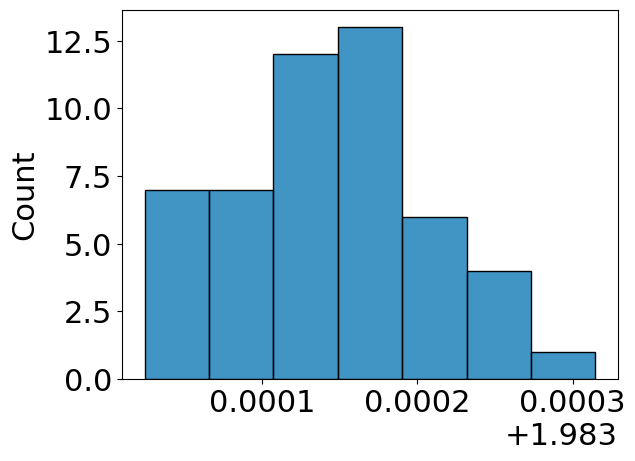

In [248]:
import seaborn
seaborn.histplot(x_ens[0, :, -1])

In [249]:
data = x_ens[0, :, :]
ci_ = []
for i in range(len(x_ens[0, 0, :])):
    d = np.array(x_ens[0, :, i])
#    print(d)
    value = stats.t.interval(0.99, df=len(d)-1, loc=np.mean(d), scale=np.std(d, ddof=1) / np.sqrt(len(d)))
    ci_.append(value)
ci = np.array(ci_)

/tmp/ipykernel_1840948/4294845406.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  d = np.array(x_ens[0, :, i])


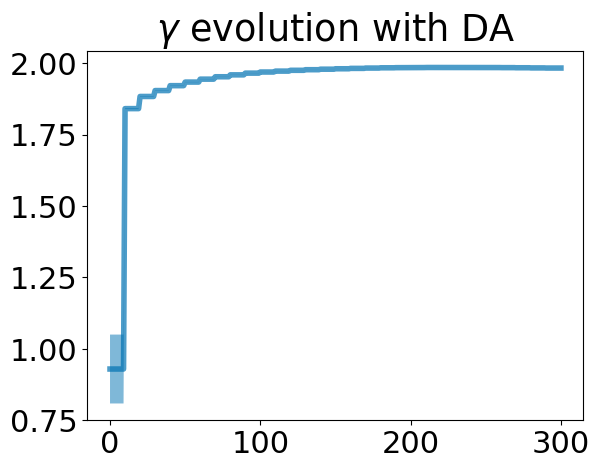

In [261]:
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({'font.size': 22})

y_mean = x_ens[0, :, :].mean(axis=0)
x = np.arange(len(y_mean))


plt.plot(x, y_mean, lw=4, alpha=.7)
#fig, ax = plt.subplots()
#ax.plot(x,y)
#plt.ylim(1.9, 2.01)
plt.title("$\\gamma$ evolution with DA")
plt.fill_between(x, ci[:, 0], ci[:, 1], alpha=.5)
plt.savefig("gamma-evolution.png")
plt.show()

In [251]:
xEnKF_noda, x_ens_noda = run_filter(300, sigens=4e-3, siggamma=0.4, gamma_initial=gamma_obs - 1, prop=10)

/tmp/ipykernel_1840948/3639613577.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  c = np.array(state_vector[1:].reshape((N, N)))
/tmp/ipykernel_1840948/390200981.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  c_hat[:] = (c_hat - dt * K2 * dfdc_hat) / (1 + dt * gamma * K2**2) # updating in time
/tmp/ipykernel_1840948/390200981.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyw

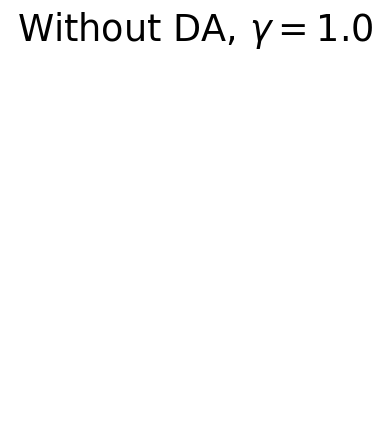

In [252]:
plt.imshow(xEnKF_noda[1:,-1].reshape(N, N),cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.title("Without DA, $\\gamma=1.0$")
plt.axis('off')
plt.savefig("without-da.png")
plt.show()

In [116]:
err_mu_noda, err_ens_noda = calc_err(xEnKF_noda[1:], x_ens_noda[1:], c_store)

/tmp/ipykernel_1840948/4293706637.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  err_mu = error(np.array(xEnKF.swapaxes(0, 1)), c_store_)
/tmp/ipykernel_1840948/4293706637.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  err_ens = error(np.array(x_ens.swapaxes(0, 1).swapaxes(1, 2)), c_store_)


In [117]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


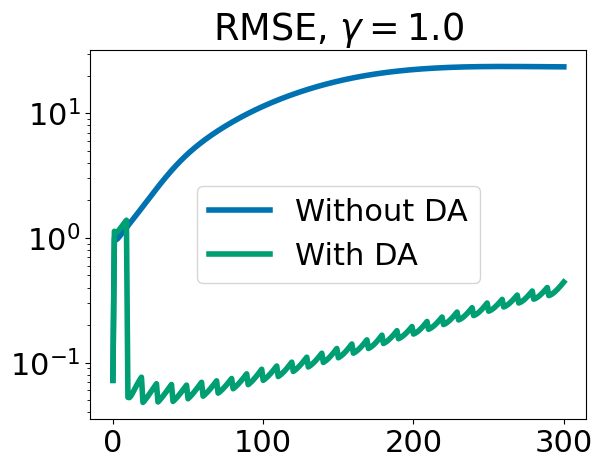

In [156]:
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({'font.size': 22})
plt.semilogy(err_mu_noda, label="Without DA", lw=4)
plt.semilogy(err_mu, label="With DA", lw=4)
plt.legend()
plt.title("RMSE, $\\gamma=1.0$")
plt.savefig('rmse-error.png')
plt.show()
